<a href="https://colab.research.google.com/github/mathivathani-1411/mathivathani-codebooster-2026/blob/main/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"panads version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")


All libraries imported successfully!
panads version:2.2.2
sqlite3 version:2.6.0


In [2]:
df=pd.read_csv('student_performance.csv')

In [5]:
print(f"Dataset loaded: {df.shape[0]} students,{df.shape[1]} columns")
print(f"columns: {df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded: 30 students,13 columns
columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [10]:
conn=sqlite3.connect("college.db")
cursor=conn.cursor()
df.to_sql(
    'students', #table name
    conn,  #connect to the database
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]
print(f"Database 'college.db' created succesfully")
print(f"Table 'students' has {count} rows")

Database 'college.db' created succesfully
Table 'students' has 30 rows


In [12]:
def run_query(sql, description="student"):
    if description:
        print(f"\n{'=' * 55}")
        print(f"{description}")
        print(f"{'=' * 55}")

    result = pd.read_sql_query(sql, conn)
    return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")


Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


In [18]:
query1="""
  SELECT student_id,name,department,math_score,attendance_percentage
  From students
  LIMIT 10
"""

result1=run_query(query1,"Query 1: First 10 students (SELECT+LIMIT)")
print(result1)



Query 1: First 10 students (SELECT+LIMIT)
   student_id          name        department  math_score  \
0        1001  Aarav Sharma  Computer Science          85   
1        1002   Priya Patel  Computer Science          76   
2        1003   Rohit Verma       Electronics          65   
3        1004   Sneha Reddy        Mechanical          70   
4        1005    Arjun Nair  Computer Science          92   
5        1006   Meera Joshi       Electronics          58   
6        1007   Kiran Kumar             Civil          73   
7        1008   Divya Singh  Computer Science          88   
8        1009  Rahul Mishra        Mechanical          62   
9        1010    Ananya Das  Computer Science          95   

   attendance_percentage  
0                     92  
1                     87  
2                     78  
3                     95  
4                     90  
5                     72  
6                     85  
7                     96  
8                     68  
9              

In [17]:
query1="""
  SELECT student_id,name
  From students
  LIMIT 5
"""

result1=run_query(query1,"Query 1: First 5 students (SELECT+LIMIT)")
print(result1)



Query 1: First 5 students (SELECT+LIMIT)
   student_id          name
0        1001  Aarav Sharma
1        1002   Priya Patel
2        1003   Rohit Verma
3        1004   Sneha Reddy
4        1005    Arjun Nair


In [19]:
query1="""
  SELECT name,department,math_score
  From students
  ORDER BY math_score DESC
  LIMIT 5
"""

result1=run_query(query1,"Query 2: Top 5 Math Scores (ORDER BY DESC +LIMIT)")
print(result1)



Query 2: Top 5 Math Scores (ORDER BY DESC +LIMIT)
             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [24]:
query1="""
  SELECT name,math_score,science_score,programming_score,attendance_percentage
  From students
  WHERE department = 'Computer Science'
  ORDER BY math_score ASC
"""

result1=run_query(query1,"Query 3: Computer Science Students(WHERE FILTER)")
print(result1)
print(f"\nTotal CS Students Found: {len(result1)}")



Query 3: Computer Science Students(WHERE FILTER)
              name  math_score  science_score  programming_score  \
0      Ajay Tiwari          71             69                 76   
1      Priya Patel          76             82                 79   
2     Nisha Kapoor          79             84                 83   
3       Suresh Rao          83             86                 88   
4    Gaurav Shukla          84             79                 87   
5     Aarav Sharma          85             78                 91   
6        Amit Bose          86             82                 89   
7      Divya Singh          88             91                 93   
8   Swati Kulkarni          90             87                 92   
9   Akanksha Yadav          91             93                 94   
10      Arjun Nair          92             88                 95   
11     Tanvi Mehta          93             90                 96   
12      Ananya Das          95             89                 97  

In [27]:
query1="""
  SELECT name,department,attendance_percentage
  From students
  WHERE attendance_percentage > 93 AND department != 'mechanical'
  ORDER BY attendance_percentage DESC
  LIMIT 3
"""

result1=run_query(query1,"Query 4: High Attendance Percentage")
print(result1)




Query 4: High Attendance Percentage
          name        department  attendance_percentage
0   Ananya Das  Computer Science                     98
1  Tanvi Mehta  Computer Science                     97
2  Divya Singh  Computer Science                     96


In [31]:
query1="""
  SELECT name
  From students
  WHERE name BETWEEN 'A' AND 'F'
"""

result1=run_query(query1,"Name from A - F")
print(result1)


Name from A - F
             name
0    Aarav Sharma
1      Arjun Nair
2     Divya Singh
3      Ananya Das
4     Ajay Tiwari
5  Deepak Chauhan
6       Amit Bose
7  Akanksha Yadav


In [40]:
query5="""
SELECT
 department ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(math_score),2)            AS avg_math,
 ROUND(AVG(science_score),2)           AS avg_science,
 ROUND(AVG(programming_score),2)       AS avg_programming,
 ROUND(AVG(attendance_percentage),2)    AS avg_attendance

FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

result2=run_query(query5,"Query 5: Department-wise Average marks")
print(result2)


Query 5: Department-wise Average marks
         department  num_students  avg_math  avg_science  avg_programming  \
0  Computer Science            13     85.62        84.46            89.23   
1        Mechanical             6     71.00        76.50            49.33   
2       Electronics             6     71.00        74.17            61.50   
3             Civil             5     63.40        66.60            40.60   

   avg_attendance  
0           90.69  
1           83.50  
2           80.33  
3           74.60  


In [ ]:
query6="""
SELECT
 department ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(math_score),2)            AS avg_math,
 ROUND(AVG(science_score),2)           AS avg_science,
 ROUND(AVG(programming_score),2)       AS avg_programming,
 ROUND(AVG(attendance_percentage),2)    AS avg_attendance

FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

result2=run_query(query6,"Query 5: Department-wise Average marks")
print(result2)

In [53]:
query6="""
SELECT
 department ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(math_score),2)            AS avg_math
FROM students
GROUP BY department
HAVING avg_math > 70
ORDER BY avg_math DESC
"""

result2=run_query(query6,"Query 5: Department with Average math > 70 (HAVING)")
print(result2)


Query 5: Department with Average math > 70 (HAVING)
         department  num_students  avg_math
0  Computer Science            13     85.62
1        Mechanical             6     71.00
2       Electronics             6     71.00


In [50]:
query6="""
SELECT
 gender ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(math_score),2)            AS avg_math,
 ROUND(AVG(science_score),2)           AS avg_science,
 ROUND(AVG(programming_score),2)       AS avg_programming,
 ROUND(AVG(attendance_percentage),2)    AS avg_attendance

FROM students
GROUP BY gender
ORDER BY avg_math DESC
"""

result2=run_query(query6,"Query 6: gender-wise performance Analysis")
print(result2)


Query 6: gender-wise performance Analysis
   gender  num_students  avg_math  avg_science  avg_programming  \
0  Female            15     78.47        81.20             70.2   
1    Male            15     73.67        74.47             65.0   

   avg_attendance  
0           88.53  
1           80.47  


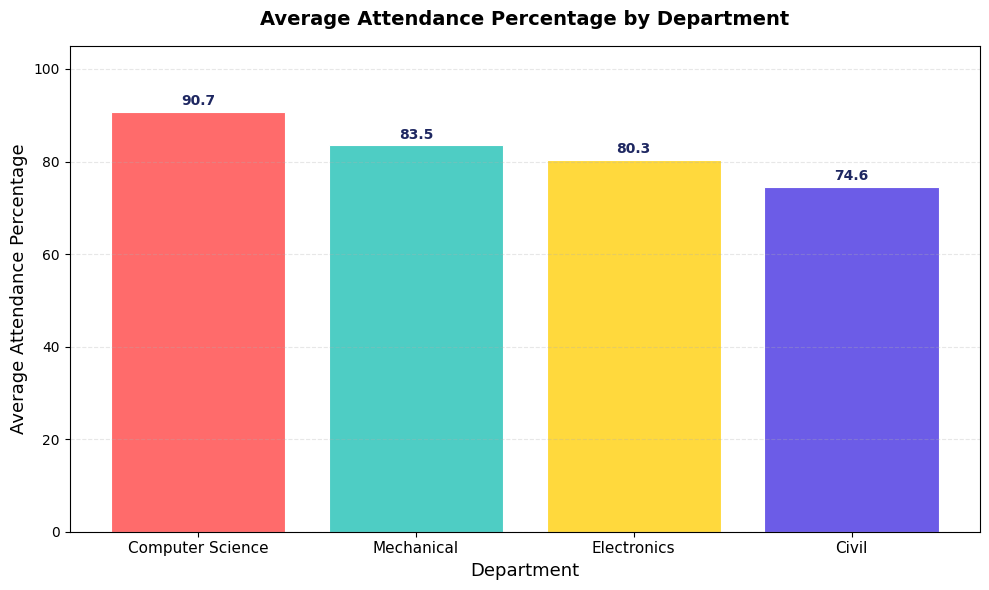

In [62]:
chart1_sql = """
SELECT department, ROUND(AVG(attendance_percentage), 2) AS avg_attend
FROM students
GROUP BY department
ORDER BY avg_attend DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6C5CE7']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_attend'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Attendance Percentage by Department',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Attendance Percentage', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

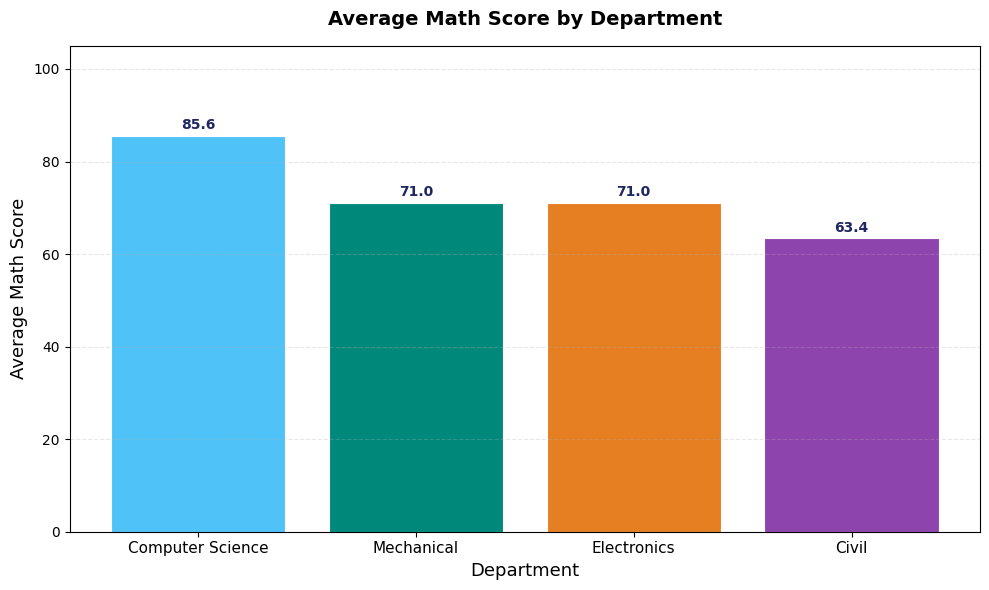

In [64]:
chart1_sql = """
SELECT department, ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Math Score by Department',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [72]:
query6="""
SELECT
 gender ,
 COUNT(*)                      AS num_students,
 ROUND(AVG(programming_score),2)       AS avg_programming
FROM students
WHERE gender = 'Female'
ORDER BY avg_programming DESC
"""

result2=run_query(query6,"Query 6: gender-wise performance Analysis")
print(result2)


Query 6: gender-wise performance Analysis
   gender  num_students  avg_programming
0  Female            15             70.2


In [76]:
query6="""
SELECT
 department ,
 COUNT(*)                      AS num_students,
 attendance_percentage      AS avg_attendance
FROM students
WHERE avg_attendance > 85
GROUP BY department
ORDER BY avg_attendance DESC
"""

result2=run_query(query6,"Query 6: gender-wise performance Analysis")
print(result2)


Query 6: gender-wise performance Analysis
         department  num_students  avg_attendance
0        Mechanical             3              95
1       Electronics             1              93
2  Computer Science            12              92


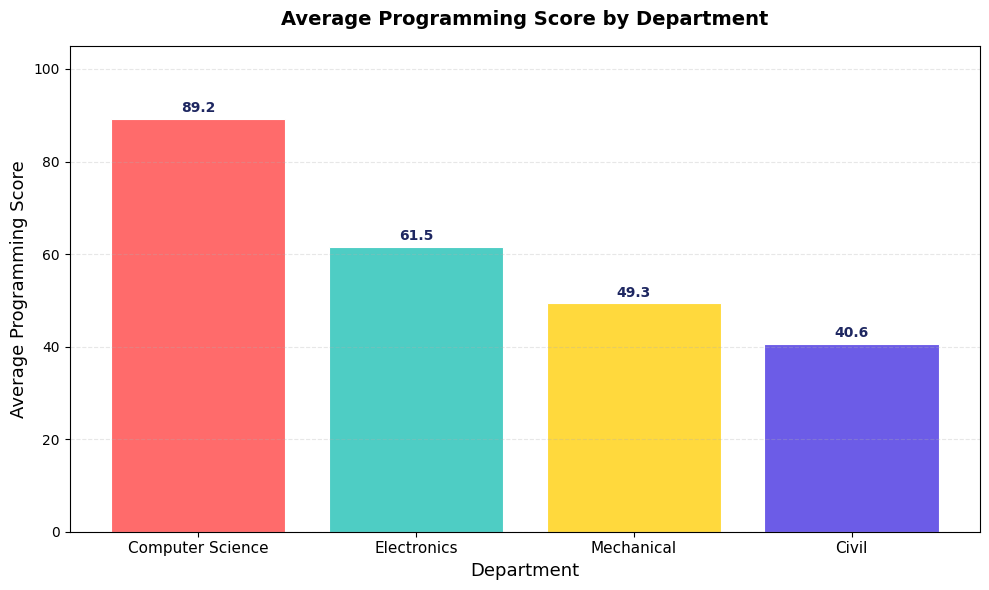

In [77]:
chart1_sql = """
SELECT department, ROUND(AVG(programming_score), 2) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6C5CE7']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_programming'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Programming Score by Department',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Programming Score', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()